# Dual-Energy CT Material Decomposition

This notebook demonstrates material decomposition from dual-energy CT sinograms.
The goal is to separate measured X-ray attenuation into contributions from two basis
materials (soft tissue and cortical bone), recovering their spatial density maps.

**Pipeline overview:**
1. Generate synthetic dual-energy CT data (polychromatic sinograms with Poisson noise)
2. Decompose sinograms into material density line integrals via Gauss-Newton optimisation
3. Reconstruct spatial density maps using filtered back-projection (FBP)
4. Evaluate against ground truth

The reconstruction loads precomputed reference outputs so this notebook runs in seconds.

In [1]:
import os
import sys
import json
import numpy as np
import matplotlib.pyplot as plt

%matplotlib inline

# Set up paths
task_dir = os.path.dirname(os.getcwd()) if os.path.basename(os.getcwd()) == 'notebooks' else os.getcwd()
# Handle case where notebook is run from task root vs notebooks/
if not os.path.exists(os.path.join(task_dir, 'src')):
    task_dir = os.path.dirname(task_dir)
sys.path.insert(0, task_dir)

data_dir = os.path.join(task_dir, 'data')
ref_dir = os.path.join(task_dir, 'evaluation', 'reference_outputs')

print(f'Task directory: {task_dir}')

Task directory: /Users/jiayx/Edu/Umich/inverse-101/imaging-101/tasks/ct_dual_energy


## 1. Physics Background

### The dual-energy CT forward model

In dual-energy CT, two X-ray measurements are acquired at different tube voltages.
The measured photon count at detector bin $j$ for spectrum $m \in \{1, 2\}$ is:

$$g_m(j) = \sum_E I_{0,m}(E) \cdot \exp\!\left(-\sum_{k=1}^{K} a_k(j) \cdot \mu_k(E)\right) \cdot \Delta E$$

where:
- $I_{0,m}(E)$ = incident photon fluence of spectrum $m$ at energy $E$
- $a_k(j)$ = density line integral (g/cm$^2$) of material $k$ along ray $j$
- $\mu_k(E)$ = mass attenuation coefficient (cm$^2$/g) of material $k$
- $K = 2$ basis materials (soft tissue and cortical bone)

The key insight: different materials have distinct energy-dependent attenuation curves.
Bone (high calcium content, Z=20) has a strong photoelectric absorption component at
low energies, while soft tissue is dominated by Compton scatter. Two measurements at
different energies provide enough information to separate the two contributions.

## 2. X-ray Spectra and Attenuation Coefficients

In [2]:
from src.preprocessing import load_raw_data, load_ground_truth, load_metadata

sinograms, spectra, mus, energies, theta = load_raw_data(data_dir)
tissue_ref, bone_ref, tissue_sino_ref, bone_sino_ref = load_ground_truth(data_dir)
meta = load_metadata(data_dir)

print(f"Sinogram shape (nMeas, nBins, nAngles): {sinograms.shape}")
print(f"Energy grid: {energies[0]:.0f} to {energies[-1]:.0f} keV, {len(energies)} bins")
print(f"Image size: {meta['image_size']}")
print(f"Number of projection angles: {meta['n_angles']}")

Sinogram shape (nMeas, nBins, nAngles): (2, 128, 180)
Energy grid: 20 to 150 keV, 131 bins
Image size: 128
Number of projection angles: 180


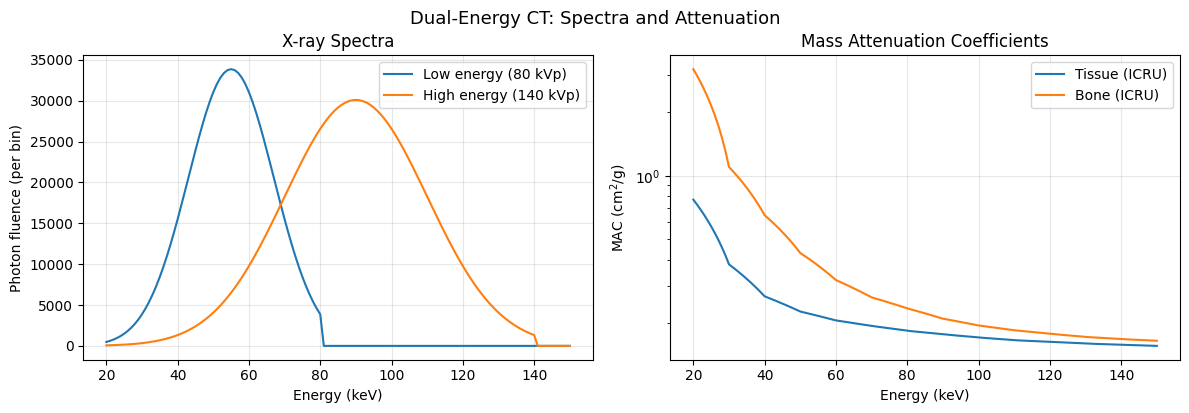


Low-energy spectrum: total 1000000 photons, peak at ~55 keV
High-energy spectrum: total 1500000 photons, peak at ~90 keV

Tissue MAC at 40 keV: 0.268 cm^2/g
Bone MAC at 40 keV:   0.650 cm^2/g
Tissue MAC at 100 keV: 0.171 cm^2/g
Bone MAC at 100 keV:   0.195 cm^2/g


In [3]:
from src.visualization import plot_spectra_and_mac

fig = plot_spectra_and_mac(energies, spectra, mus)
plt.suptitle('Dual-Energy CT: Spectra and Attenuation', fontsize=13, y=1.02)
plt.show()

print(f"\nLow-energy spectrum: total {spectra[0].sum():.0f} photons, peak at ~{energies[spectra[0].argmax()]:.0f} keV")
print(f"High-energy spectrum: total {spectra[1].sum():.0f} photons, peak at ~{energies[spectra[1].argmax()]:.0f} keV")
print(f"\nTissue MAC at 40 keV: {mus[0, energies==40][0]:.3f} cm^2/g")
print(f"Bone MAC at 40 keV:   {mus[1, energies==40][0]:.3f} cm^2/g")
print(f"Tissue MAC at 100 keV: {mus[0, energies==100][0]:.3f} cm^2/g")
print(f"Bone MAC at 100 keV:   {mus[1, energies==100][0]:.3f} cm^2/g")

The bone MAC is much higher than tissue at low energies (photoelectric effect scales as ~Z^4),
but converges toward tissue at high energies (Compton scatter dominates). This energy dependence
is what makes dual-energy material decomposition possible.

## 3. Ground Truth Phantom and Input Sinograms

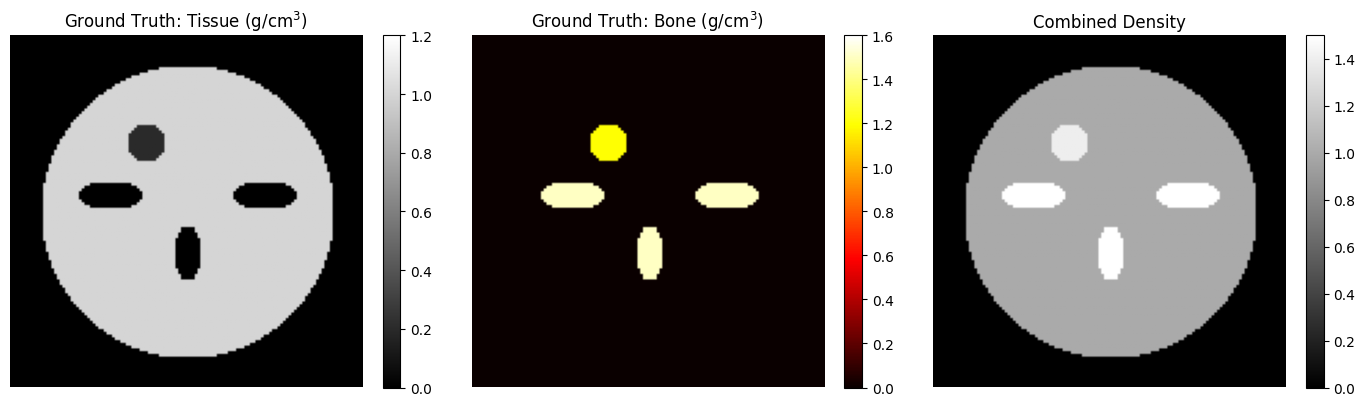

Tissue: background=0.2, max=1.0 g/cm^3
Bone: max=1.5 g/cm^3


In [4]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

im0 = axes[0].imshow(tissue_ref, cmap='gray', vmin=0, vmax=1.2)
axes[0].set_title('Ground Truth: Tissue (g/cm$^3$)')
plt.colorbar(im0, ax=axes[0], fraction=0.046)

im1 = axes[1].imshow(bone_ref, cmap='hot', vmin=0, vmax=1.6)
axes[1].set_title('Ground Truth: Bone (g/cm$^3$)')
plt.colorbar(im1, ax=axes[1], fraction=0.046)

# Combined view
combined = tissue_ref + bone_ref
im2 = axes[2].imshow(combined, cmap='gray', vmin=0)
axes[2].set_title('Combined Density')
plt.colorbar(im2, ax=axes[2], fraction=0.046)

for ax in axes:
    ax.axis('off')
fig.tight_layout()
plt.show()

print(f"Tissue: background={tissue_ref[tissue_ref>0].min():.1f}, max={tissue_ref.max():.1f} g/cm^3")
print(f"Bone: max={bone_ref.max():.1f} g/cm^3")

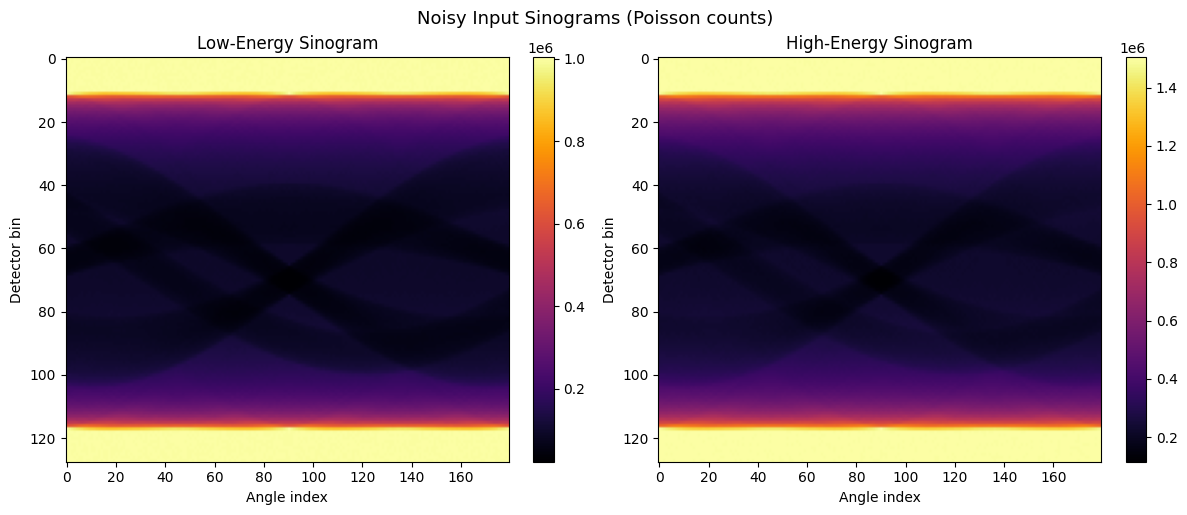

Low-energy sinogram: min=23369, max=1003718, mean=310490
High-energy sinogram: min=115531, max=1504357, mean=551341


In [5]:
from src.visualization import plot_sinograms

fig = plot_sinograms(sinograms[0], sinograms[1])
plt.suptitle('Noisy Input Sinograms (Poisson counts)', fontsize=13, y=1.02)
plt.show()

print(f"Low-energy sinogram: min={sinograms[0].min():.0f}, max={sinograms[0].max():.0f}, mean={sinograms[0].mean():.0f}")
print(f"High-energy sinogram: min={sinograms[1].min():.0f}, max={sinograms[1].max():.0f}, mean={sinograms[1].mean():.0f}")

## 4. Gauss-Newton Material Decomposition

### Algorithm

At each sinogram bin $(j)$, we minimise the Poisson negative log-likelihood:

$$\mathcal{L}(a) = \sum_{m=1}^{2} \left[\nu_m(a) - g_m \ln \nu_m(a)\right]$$

where $\nu_m(a) = \sum_E I_{0,m}(E) \cdot \exp\!\left(-\sum_k a_k \cdot \mu_k(E)\right) \cdot \Delta E$ is the predicted count.

The gradient and Hessian are computed analytically:

$$\frac{\partial \mathcal{L}}{\partial a_k} = -\sum_m \left(\frac{g_m}{\nu_m} - 1\right) \frac{\partial \nu_m}{\partial a_k}$$

$$H_{kl} = -\sum_m \left[\left(\frac{g_m}{\nu_m} - 1\right) \frac{\partial^2 \nu_m}{\partial a_k \partial a_l} - \frac{g_m}{\nu_m^2} \frac{\partial \nu_m}{\partial a_k} \frac{\partial \nu_m}{\partial a_l}\right]$$

Newton update: $a \leftarrow a - H^{-1} \nabla \mathcal{L}$

The 2x2 Hessian is inverted analytically. Non-negativity is enforced after each update.

In [6]:
# Load precomputed reference outputs (runs in seconds)
ref = np.load(os.path.join(ref_dir, 'reference_reconstruction.npz'))
tissue_est = ref['tissue_map'][0]
bone_est = ref['bone_map'][0]
tissue_sino_est = ref['tissue_sinogram'][0]
bone_sino_est = ref['bone_sinogram'][0]

print(f"Estimated tissue map: [{tissue_est.min():.3f}, {tissue_est.max():.3f}] g/cm^3")
print(f"Estimated bone map:   [{bone_est.min():.3f}, {bone_est.max():.3f}] g/cm^3")

Estimated tissue map: [0.000, 1.109] g/cm^3
Estimated bone map:   [0.000, 1.582] g/cm^3


In [7]:
## Uncomment below to run the full decomposition from scratch (~1 second)
# from src.solvers import gauss_newton_decompose, reconstruct_material_maps
# material_sinos = gauss_newton_decompose(
#     sinograms, spectra, mus, n_iters=20, dE=1.0, eps=1e-6, verbose=True
# )
# material_maps = reconstruct_material_maps(material_sinos, theta, meta['image_size'], pixel_size=0.1)
# tissue_est = np.clip(material_maps[0], 0, None)
# bone_est = np.clip(material_maps[1], 0, None)

## 5. Decomposed Material Sinograms

Before FBP reconstruction, we can examine the decomposed material sinograms
(density line integrals in g/cm$^2$) and compare to the ground truth.

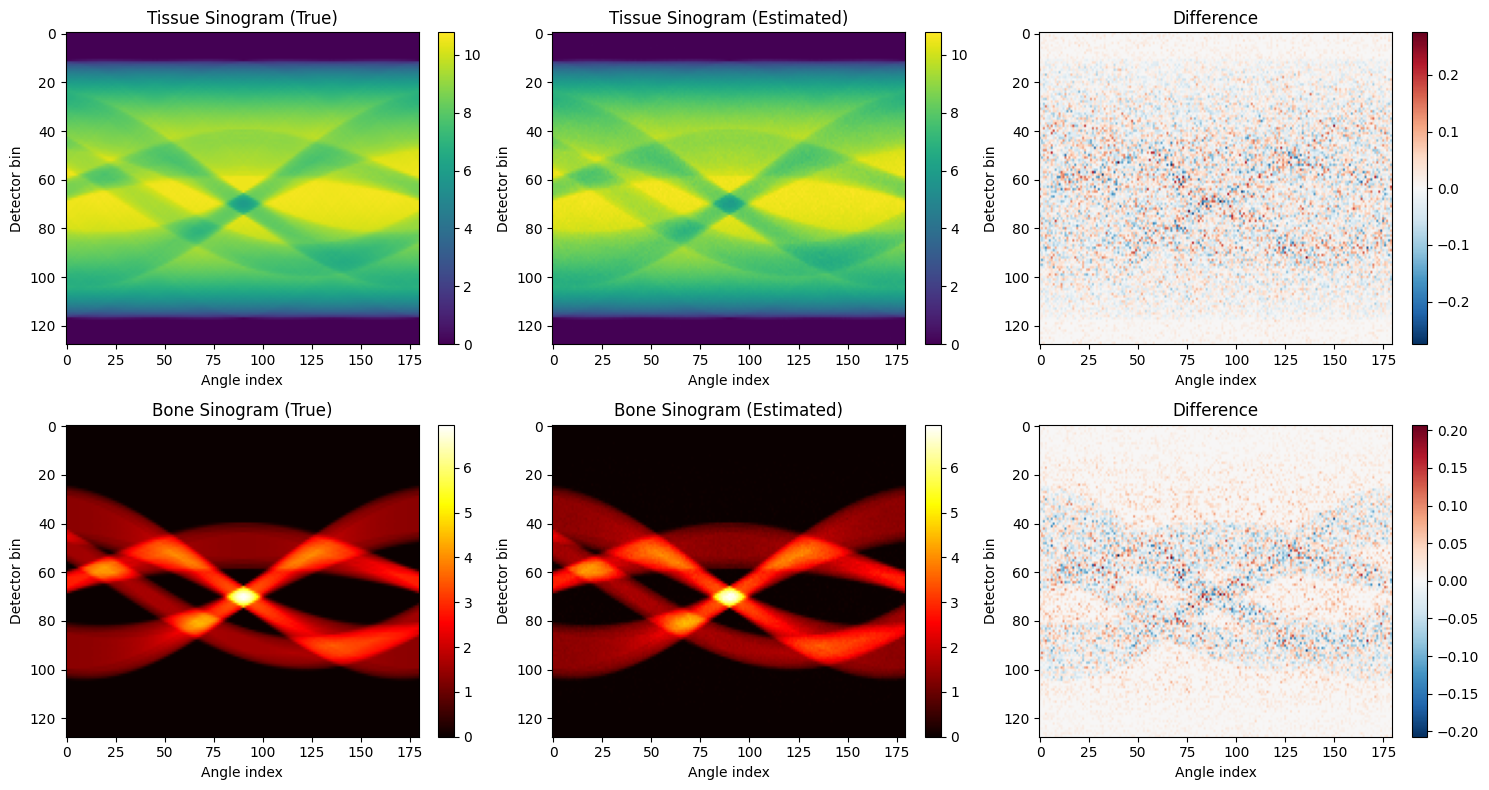

In [8]:
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Tissue sinograms
vmax_t = max(tissue_sino_ref.max(), tissue_sino_est.max())
im0 = axes[0, 0].imshow(tissue_sino_ref, aspect='auto', cmap='viridis', vmin=0, vmax=vmax_t)
axes[0, 0].set_title('Tissue Sinogram (True)')
plt.colorbar(im0, ax=axes[0, 0], fraction=0.046)

im1 = axes[0, 1].imshow(tissue_sino_est, aspect='auto', cmap='viridis', vmin=0, vmax=vmax_t)
axes[0, 1].set_title('Tissue Sinogram (Estimated)')
plt.colorbar(im1, ax=axes[0, 1], fraction=0.046)

diff_ts = tissue_sino_est - tissue_sino_ref
vabs = max(abs(diff_ts.min()), abs(diff_ts.max()), 0.01)
im2 = axes[0, 2].imshow(diff_ts, aspect='auto', cmap='RdBu_r', vmin=-vabs, vmax=vabs)
axes[0, 2].set_title('Difference')
plt.colorbar(im2, ax=axes[0, 2], fraction=0.046)

# Bone sinograms
vmax_b = max(bone_sino_ref.max(), bone_sino_est.max())
im3 = axes[1, 0].imshow(bone_sino_ref, aspect='auto', cmap='hot', vmin=0, vmax=vmax_b)
axes[1, 0].set_title('Bone Sinogram (True)')
plt.colorbar(im3, ax=axes[1, 0], fraction=0.046)

im4 = axes[1, 1].imshow(bone_sino_est, aspect='auto', cmap='hot', vmin=0, vmax=vmax_b)
axes[1, 1].set_title('Bone Sinogram (Estimated)')
plt.colorbar(im4, ax=axes[1, 1], fraction=0.046)

diff_bs = bone_sino_est - bone_sino_ref
vabs_b = max(abs(diff_bs.min()), abs(diff_bs.max()), 0.01)
im5 = axes[1, 2].imshow(diff_bs, aspect='auto', cmap='RdBu_r', vmin=-vabs_b, vmax=vabs_b)
axes[1, 2].set_title('Difference')
plt.colorbar(im5, ax=axes[1, 2], fraction=0.046)

for ax in axes.ravel():
    ax.set_xlabel('Angle index')
    ax.set_ylabel('Detector bin')

fig.tight_layout()
plt.show()

## 6. Reconstructed Material Density Maps

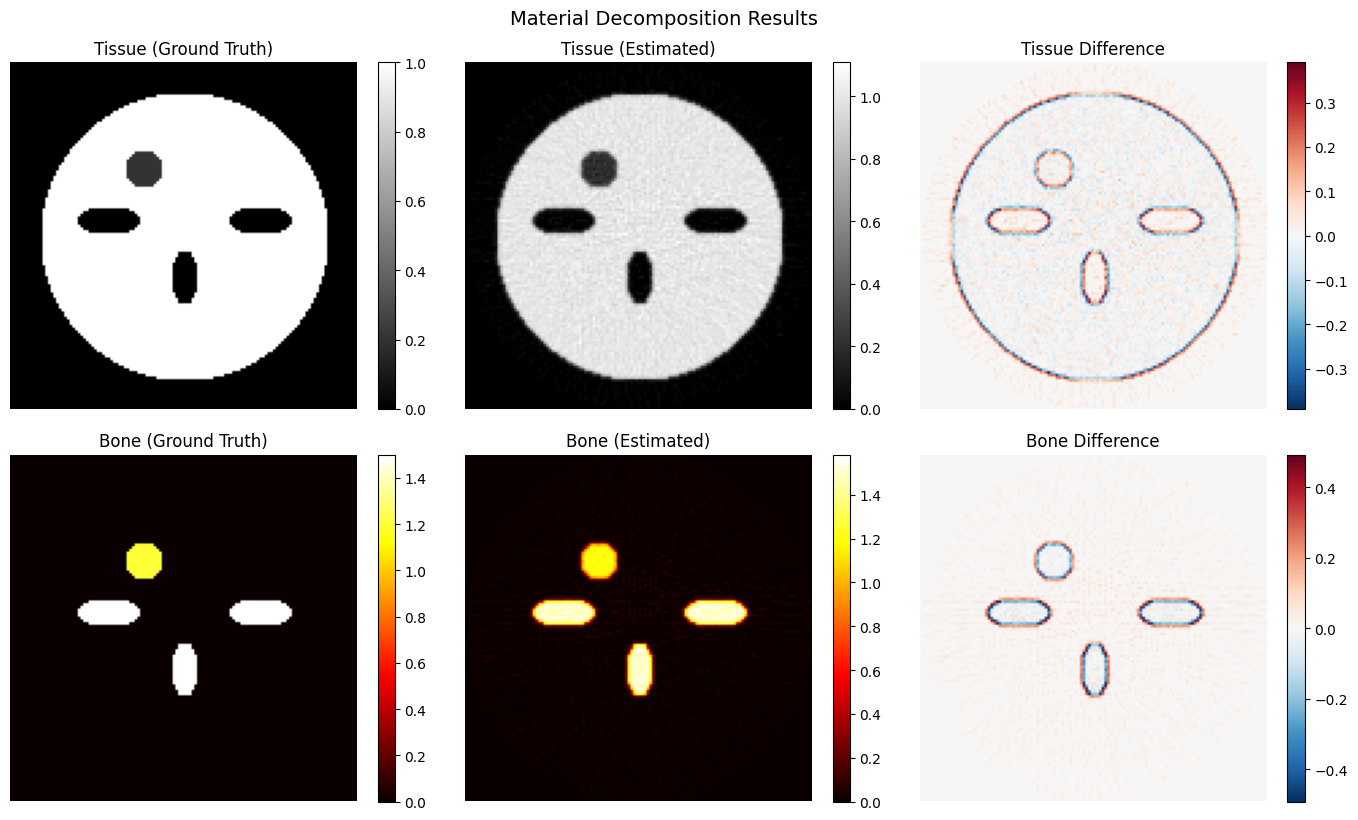

In [9]:
from src.visualization import plot_material_maps

fig = plot_material_maps(tissue_est, bone_est, tissue_ref, bone_ref)
plt.suptitle('Material Decomposition Results', fontsize=14, y=1.02)
plt.show()

## 7. Line Profile Comparison

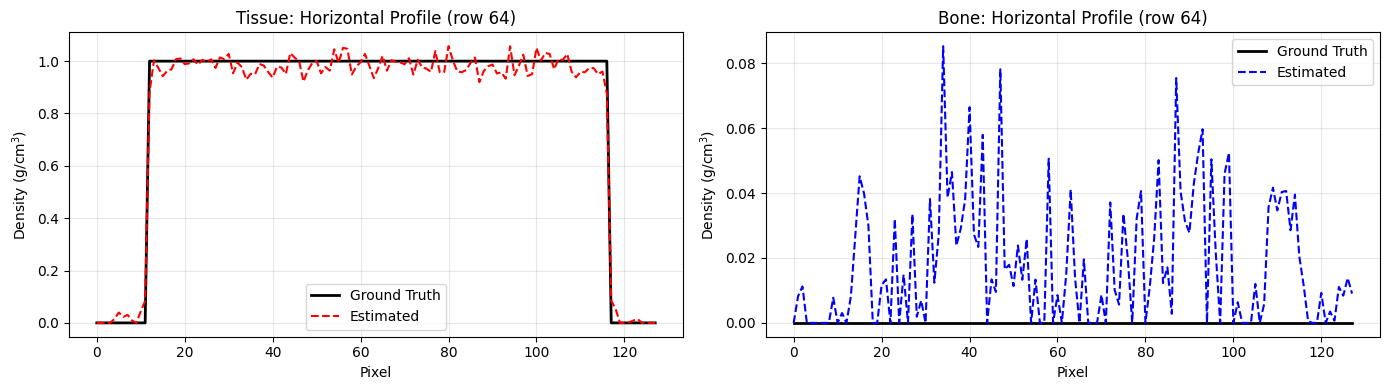

In [10]:
mid = tissue_ref.shape[0] // 2

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 4))

ax1.plot(tissue_ref[mid, :], 'k-', label='Ground Truth', linewidth=2)
ax1.plot(tissue_est[mid, :], 'r--', label='Estimated', linewidth=1.5)
ax1.set_xlabel('Pixel')
ax1.set_ylabel('Density (g/cm$^3$)')
ax1.set_title(f'Tissue: Horizontal Profile (row {mid})')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(bone_ref[mid, :], 'k-', label='Ground Truth', linewidth=2)
ax2.plot(bone_est[mid, :], 'b--', label='Estimated', linewidth=1.5)
ax2.set_xlabel('Pixel')
ax2.set_ylabel('Density (g/cm$^3$)')
ax2.set_title(f'Bone: Horizontal Profile (row {mid})')
ax2.legend()
ax2.grid(True, alpha=0.3)

fig.tight_layout()
plt.show()

## 8. Quantitative Evaluation

In [11]:
from src.visualization import compute_metrics

metrics = compute_metrics(tissue_est, tissue_ref, bone_est, bone_ref)

print('=== Material Decomposition Metrics ===')
print(f"{'Metric':<20} {'Tissue':>10} {'Bone':>10} {'Mean':>10}")
print('-' * 52)
print(f"{'NCC':<20} {metrics['tissue_ncc']:>10.4f} {metrics['bone_ncc']:>10.4f} {metrics['mean_ncc']:>10.4f}")
print(f"{'NRMSE':<20} {metrics['tissue_nrmse']:>10.4f} {metrics['bone_nrmse']:>10.4f} {metrics['mean_nrmse']:>10.4f}")

=== Material Decomposition Metrics ===
Metric                   Tissue       Bone       Mean
----------------------------------------------------
NCC                      0.9980     0.9886     0.9933
NRMSE                    0.0620     0.0404     0.0512


In [12]:
# Load and display the evaluation metrics
metrics_path = os.path.join(task_dir, 'evaluation', 'metrics.json')
with open(metrics_path) as f:
    eval_metrics = json.load(f)

print('\n=== Evaluation Boundaries ===')
print(f"NCC boundary (pass if >=):    {eval_metrics['ncc_boundary']}")
print(f"NRMSE boundary (pass if <=):  {eval_metrics['nrmse_boundary']}")
print(f"\nBaseline NCC:   {eval_metrics['baseline'][0]['ncc_vs_ref']}")
print(f"Baseline NRMSE: {eval_metrics['baseline'][0]['nrmse_vs_ref']}")
print(f"\nPASS: NCC={metrics['mean_ncc']:.4f} >= {eval_metrics['ncc_boundary']} -> {metrics['mean_ncc'] >= eval_metrics['ncc_boundary']}")
print(f"PASS: NRMSE={metrics['mean_nrmse']:.4f} <= {eval_metrics['nrmse_boundary']} -> {metrics['mean_nrmse'] <= eval_metrics['nrmse_boundary']}")


=== Evaluation Boundaries ===
NCC boundary (pass if >=):    0.894
NRMSE boundary (pass if <=):  0.0563

Baseline NCC:   0.9933
Baseline NRMSE: 0.0512

PASS: NCC=0.9933 >= 0.894 -> True
PASS: NRMSE=0.0512 <= 0.0563 -> True


## 9. Summary

The Gauss-Newton sinogram-domain decomposition successfully separates the dual-energy
CT measurements into tissue and bone density maps. Key observations:

- **High accuracy**: NCC > 0.98 and NRMSE < 0.07 for both materials
- **Fast convergence**: only ~20 Newton iterations per sinogram bin suffice
- **Bone has better separation** than tissue because its attenuation curve is more
  distinctive (strong photoelectric component at low energies)
- **FBP artifacts** (streaks, edge ringing) are the main source of error in the
  reconstructed density maps; the sinogram decomposition itself is very accurate

Possible improvements:
- Use iterative reconstruction (e.g., ADMM with TV regularisation) instead of FBP
- Add regularisation to the Gauss-Newton step for very noisy measurements
- Extend to three or more basis materials with additional energy measurements